## UK House Prices
### Notebook 1 - Data Cleaning and Preparation

Source
https://www.gov.uk/government/statistical-data-sets/uk-house-price-index-data-downloads-december-

Information on dataset
https://www.gov.uk/government/publications/about-the-uk-house-price-index/about-the-uk-house-price-index#data-tables


1. Import house prices dataset
2. Initial data inspection
3. Drop variables not required

   

In [78]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

### 1. Import house prices dataset

In [79]:
filepath = "../data/UK-HPI-full-file-2025-12.csv"

#### Create a dataframe from csv

In [80]:
data = pd.read_csv(filepath)

### 2. Initial data inspection

#### Examine data

In [81]:
print(f"Data shape:{data.shape}")
data.head()

Data shape:(149085, 54)


,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


In [82]:
data.describe()

,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,DetachedPrice,DetachedIndex,Detached1m%Change,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
count,1.490850e+05,149085.000000,5244.000000,148632.000000,144225.000000,5244.000000,144618.000000,1.422840e+05,142284.000000,141889.000000,...,1.416640e+05,141664.000000,141268.000000,136936.000000,138483.000000,1.418680e+05,141868.000000,141472.000000,137140.000000,141858.000000
mean,1.831012e+05,59.835763,62.132113,0.526866,6.100826,168752.656941,1252.600105,3.420380e+05,59.933395,0.461848,...,2.196692e+05,61.681981,0.497958,6.245756,135.956161,1.847985e+05,60.045649,0.472946,6.054274,1138.200045
std,1.311841e+05,26.619737,25.039764,1.934405,8.622357,94882.354669,7707.191260,3.432452e+05,25.206280,1.697813,...,1.342548e+05,26.401143,1.751680,7.974581,843.840990,1.310111e+05,25.507217,1.730925,8.408653,6965.933714
min,2.553000e+03,0.800000,13.900000,-30.300000,-35.800000,39008.000000,2.000000,4.011700e+04,9.400000,-19.600000,...,2.244300e+04,8.000000,-29.800000,-28.900000,1.000000,2.271600e+04,9.000000,-30.600000,-30.300000,2.000000
25%,1.005410e+05,38.200000,46.600000,-0.500000,1.100000,116135.000000,140.000000,1.785228e+05,41.200000,-0.500000,...,1.279912e+05,42.400000,-0.500000,1.700000,10.000000,1.021160e+05,40.900000,-0.500000,1.000000,126.000000
50%,1.547560e+05,61.000000,62.600000,0.500000,5.100000,153018.500000,215.000000,2.603840e+05,60.000000,0.400000,...,1.982200e+05,61.600000,0.500000,5.400000,21.000000,1.549365e+05,60.800000,0.500000,5.100000,193.000000
75%,2.301380e+05,80.300000,80.400000,1.400000,10.100000,209241.750000,376.000000,3.961765e+05,79.800000,1.400000,...,2.780390e+05,82.800000,1.500000,10.100000,46.000000,2.312262e+05,79.600000,1.400000,10.200000,343.000000
max,1.656986e+06,153.100000,110.000000,35.300000,98.400000,574627.000000,183609.000000,5.820174e+06,147.000000,34.800000,...,1.414204e+06,149.600000,34.900000,96.200000,21097.000000,1.665089e+06,152.700000,35.600000,98.600000,166098.000000


#### Review missing variables


In [83]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 149085 entries, 0 to 149084
Data columns (total 54 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    149085 non-null  str    
 1   RegionName              149085 non-null  str    
 2   AreaCode                149085 non-null  str    
 3   AveragePrice            149085 non-null  int64  
 4   Index                   149085 non-null  float64
 5   IndexSA                 5244 non-null    float64
 6   1m%Change               148632 non-null  float64
 7   12m%Change              144225 non-null  float64
 8   AveragePriceSA          5244 non-null    float64
 9   SalesVolume             144618 non-null  float64
 10  DetachedPrice           142284 non-null  float64
 11  DetachedIndex           142284 non-null  float64
 12  Detached1m%Change       141889 non-null  float64
 13  Detached12m%Change      137568 non-null  float64
 14  SemiDetachedPrice       142284 

We can see there are 53 columns, and a lot have missing values. We will reduce some of these features down.
Some of these variables are essentially the same - Average Price, Index, IndexSA and AveragePrice SA, but let's inspect the index to see how it is implemented.

In [84]:
data.groupby('RegionName')['Index'].describe().sort_values(by='max',ascending=False)

,count,mean,std,min,25%,50%,75%,max
RegionName,,,,,,,,
City of Aberdeen,264.0,114.121591,20.735505,55.1,103.950,117.60,126.125,153.1
Ards and North Down,252.0,87.740476,19.193993,62.2,73.150,81.50,101.325,140.5
Mid Ulster,252.0,85.641667,19.480325,55.7,71.300,81.00,100.250,137.2
Armagh City Banbridge and Craigavon,252.0,83.413095,19.761751,54.7,69.450,78.00,97.975,137.1
Belfast,252.0,85.039286,18.872139,55.5,70.900,81.65,99.550,134.8
...,...,...,...,...,...,...,...,...
Sutton,372.0,56.766667,26.220627,15.4,38.200,52.10,82.900,100.0
Croydon,372.0,57.647849,26.250962,16.0,39.275,52.30,86.825,100.0
Thanet,372.0,51.231183,25.236037,12.7,31.850,48.20,73.375,100.0


In [85]:
print(data[data['Index']==100.0])

              Date                RegionName   AreaCode  AveragePrice  Index  \
228     01/01/2023             Aberdeenshire  S12000034        205782  100.0   
244     01/05/2024             Aberdeenshire  S12000034        205704  100.0   
600     01/01/2023                      Adur  E07000223        376960  100.0   
970     01/11/2022              Amber Valley  E07000032        221949  100.0   
972     01/01/2023              Amber Valley  E07000032        221983  100.0   
...            ...                       ...        ...           ...    ...   
148356  01/01/2023                      York  E06000014        307384  100.0   
148371  01/04/2024                      York  E06000014        307508  100.0   
149049  01/01/2023  Yorkshire and The Humber  E12000003        191628  100.0   
149050  01/02/2023  Yorkshire and The Humber  E12000003        191681  100.0   
149061  01/01/2024  Yorkshire and The Humber  E12000003        191618  100.0   

        IndexSA  1m%Change  12m%Change 

So we can see all seem to start at different indexes, and City of Aberdeen seems to contain the highest. Indexes are set for individual counties at some point, and are changed from that original zero index.

Variables such as 1m% change and 12m% change are encoding growth.

Then there is segmented market data; splitting into type of property; detached, semi-detached, flat, purchase type; mortgage, cash, buyer type and age (new/old). We will drop the segmented market data, to focus on modelling across these segments.

### Drop variables not required

So we will keep 'Date', 'RegionName', 'AreaCode', 'AveragePrice', 'Index', '1m%Change', '12m%Change', 'SalesVolume'. 

In [86]:
data = data[['Date','RegionName','AreaCode','AveragePrice','Index','1m%Change','12m%Change','SalesVolume']]

### Check duplicate data

In [87]:
data.duplicated().sum()

np.int64(0)

### Missing data

OK good there are no duplicates, now we can check what's missing.

In [88]:
data.isna().sum()

Date               0
RegionName         0
AreaCode           0
AveragePrice       0
Index              0
1m%Change        453
12m%Change      4860
SalesVolume     4467
dtype: int64

There are a lot of missing values for 1m%Change and 12m%Change as well as SalesVolume.

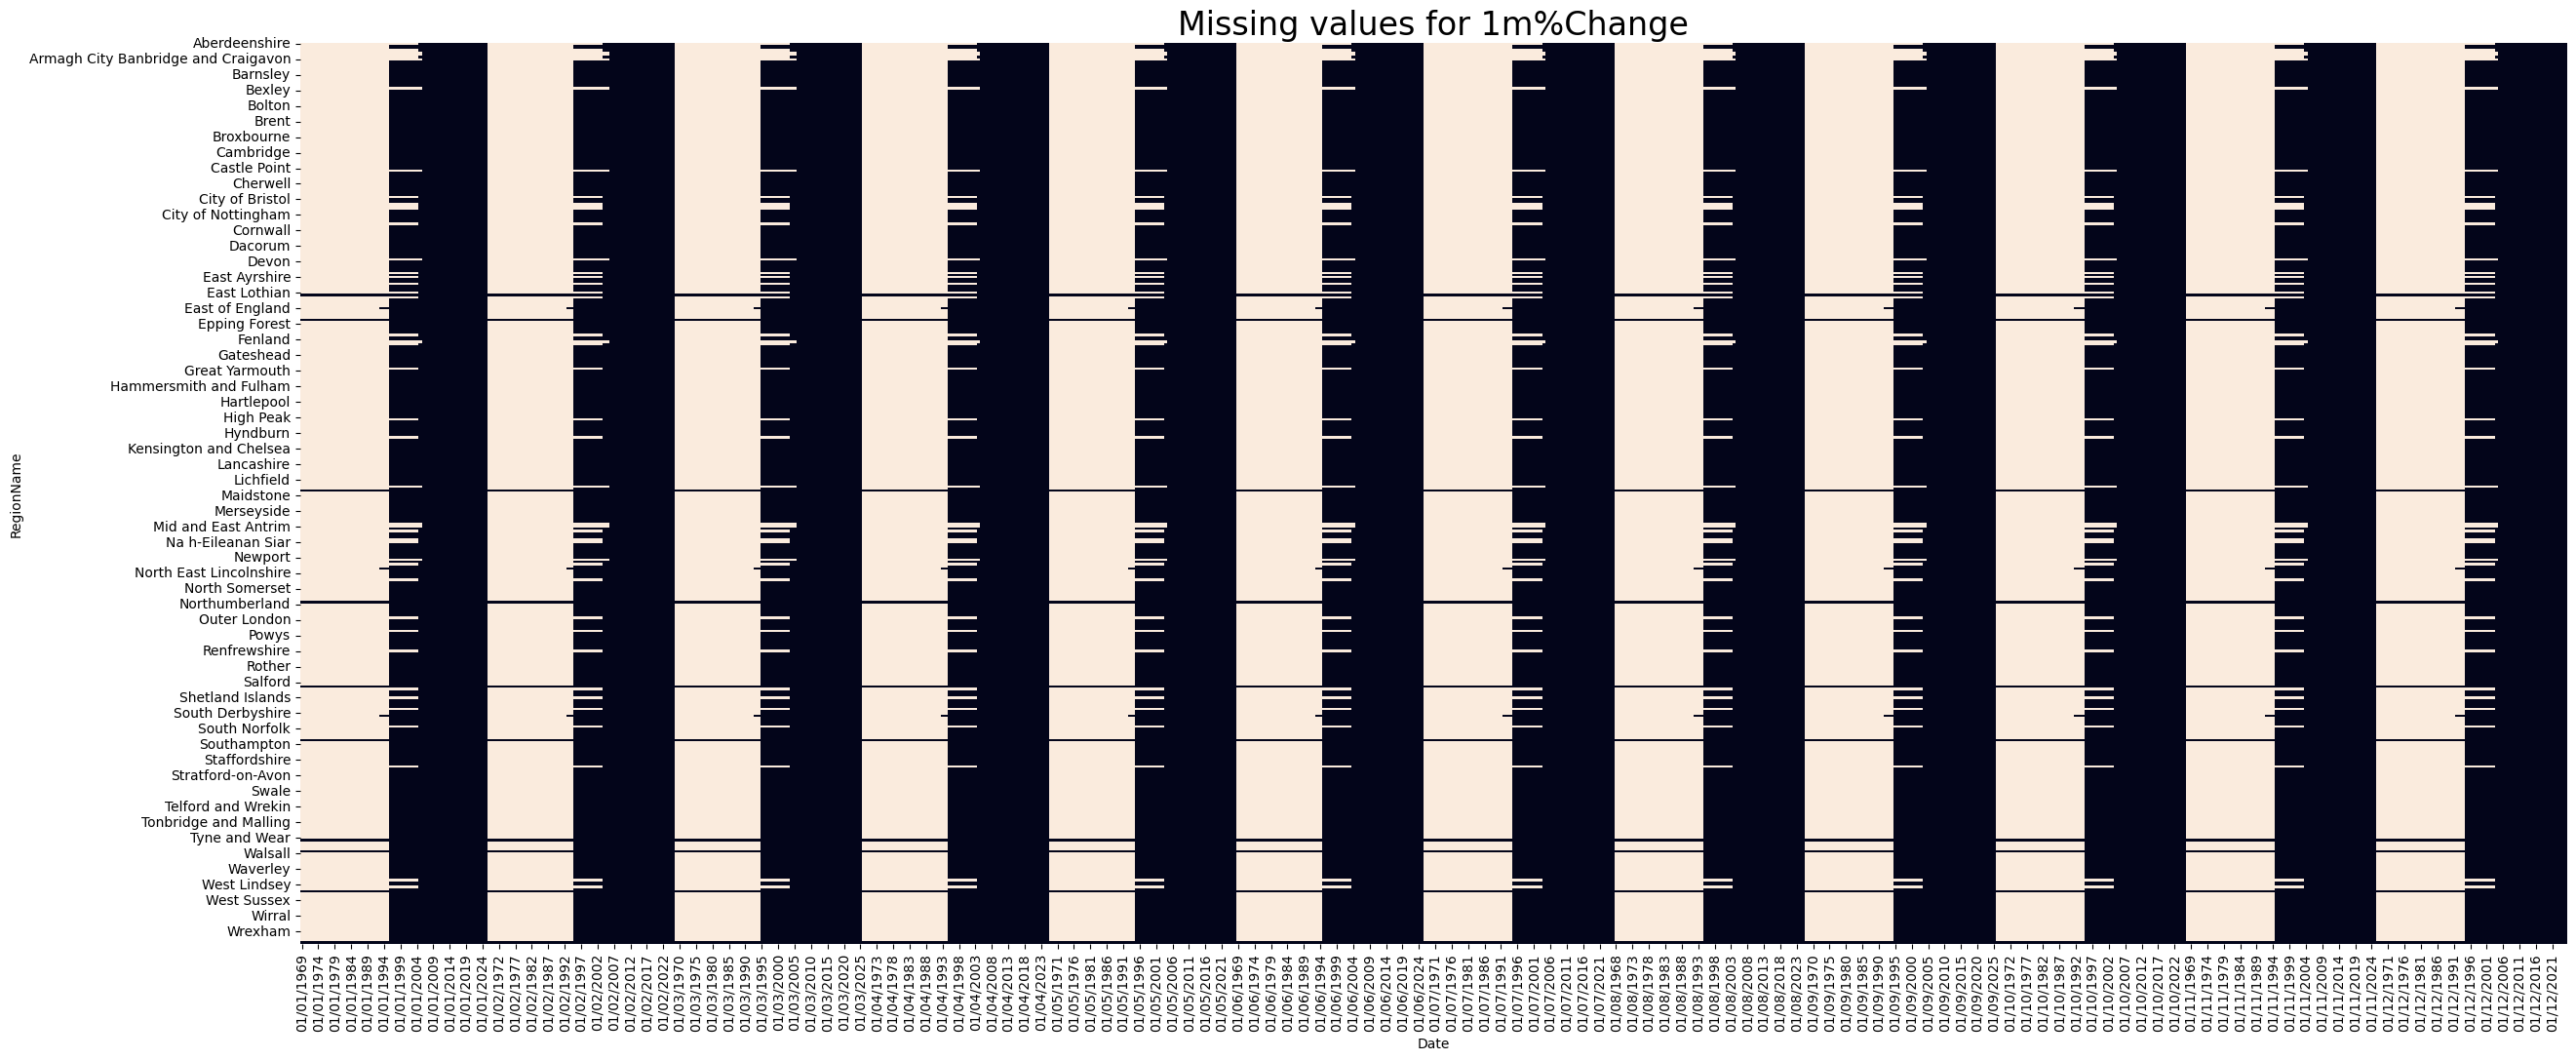

In [89]:
piv_tab = data.pivot_table(values='1m%Change',index='RegionName',columns='Date')
import seaborn as sns
plt.figure(figsize=(30,12))

sns.heatmap(piv_tab.isna(),cbar=False)
plt.title("Missing values for 1m%Change",fontsize=24)
plt.show()

It looks like we need to do some work on the dates

### Clean dates

__Ok so now we have cleanly assigned all counties to a region, we may want to check the state of the dates. What we need is the same set of dates for all counties, so we can aggregate across counties for each date.__

In [90]:
print(data.groupby('RegionName')['Date'].unique())

RegionName
Aberdeenshire               [01/01/2004, 01/02/2004, 01/03/2004, 01/04/200...
Adur                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Amber Valley                [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Angus                       [01/01/2004, 01/02/2004, 01/03/2004, 01/04/200...
Antrim and Newtownabbey     [01/01/2005, 01/02/2005, 01/03/2005, 01/04/200...
                                                  ...                        
Wychavon                    [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Wyre                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Wyre Forest                 [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
York                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Yorkshire and The Humber    [01/04/1968, 01/05/1968, 01/06/1968, 01/07/196...
Name: Date, Length: 405, dtype: object


__Oh dear this looks messy.__
__All counties obviously don't have the same dates, but it looks like we could be quite a long way off.__
__Let's create a new dataframe based on a new index with dates and counties as indexes__

In [91]:
# check datetime format
print(type(data['Date'][0]))

<class 'str'>


In [92]:
data['Date'] = pd.to_datetime(
    data['Date'].astype(str).str.strip(),
    format='%d/%m/%Y',
    errors='raise'
)

In [93]:
# check formatting
data['Date'].head(10).apply(lambda x: (x, x.day, x.month))

0     (2004-01-01 00:00:00, 1, 1)
1     (2004-02-01 00:00:00, 1, 2)
2     (2004-03-01 00:00:00, 1, 3)
3     (2004-04-01 00:00:00, 1, 4)
4     (2004-05-01 00:00:00, 1, 5)
5     (2004-06-01 00:00:00, 1, 6)
6     (2004-07-01 00:00:00, 1, 7)
7     (2004-08-01 00:00:00, 1, 8)
8     (2004-09-01 00:00:00, 1, 9)
9    (2004-10-01 00:00:00, 1, 10)
Name: Date, dtype: object

In [95]:
data.sort_values(by=['RegionName','Date'])

,Date,RegionName,AreaCode,AveragePrice,Index,1m%Change,12m%Change,SalesVolume
0,2004-01-01,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,388.0
1,2004-02-01,Aberdeenshire,S12000034,84623,41.1,0.0,NaN,326.0
2,2004-03-01,Aberdeenshire,S12000034,86536,42.1,2.3,NaN,453.0
3,2004-04-01,Aberdeenshire,S12000034,87373,42.5,1.0,NaN,571.0
4,2004-05-01,Aberdeenshire,S12000034,89493,43.5,2.4,NaN,502.0
...,...,...,...,...,...,...,...,...
149080,2025-08-01,Yorkshire and The Humber,E12000003,206107,107.6,0.9,2.0,5471.0
149081,2025-09-01,Yorkshire and The Humber,E12000003,206581,107.8,0.2,3.9,4745.0
149082,2025-10-01,Yorkshire and The Humber,E12000003,206401,107.7,-0.1,3.2,4961.0
149083,2025-11-01,Yorkshire and The Humber,E12000003,209467,109.3,1.5,3.8,NaN


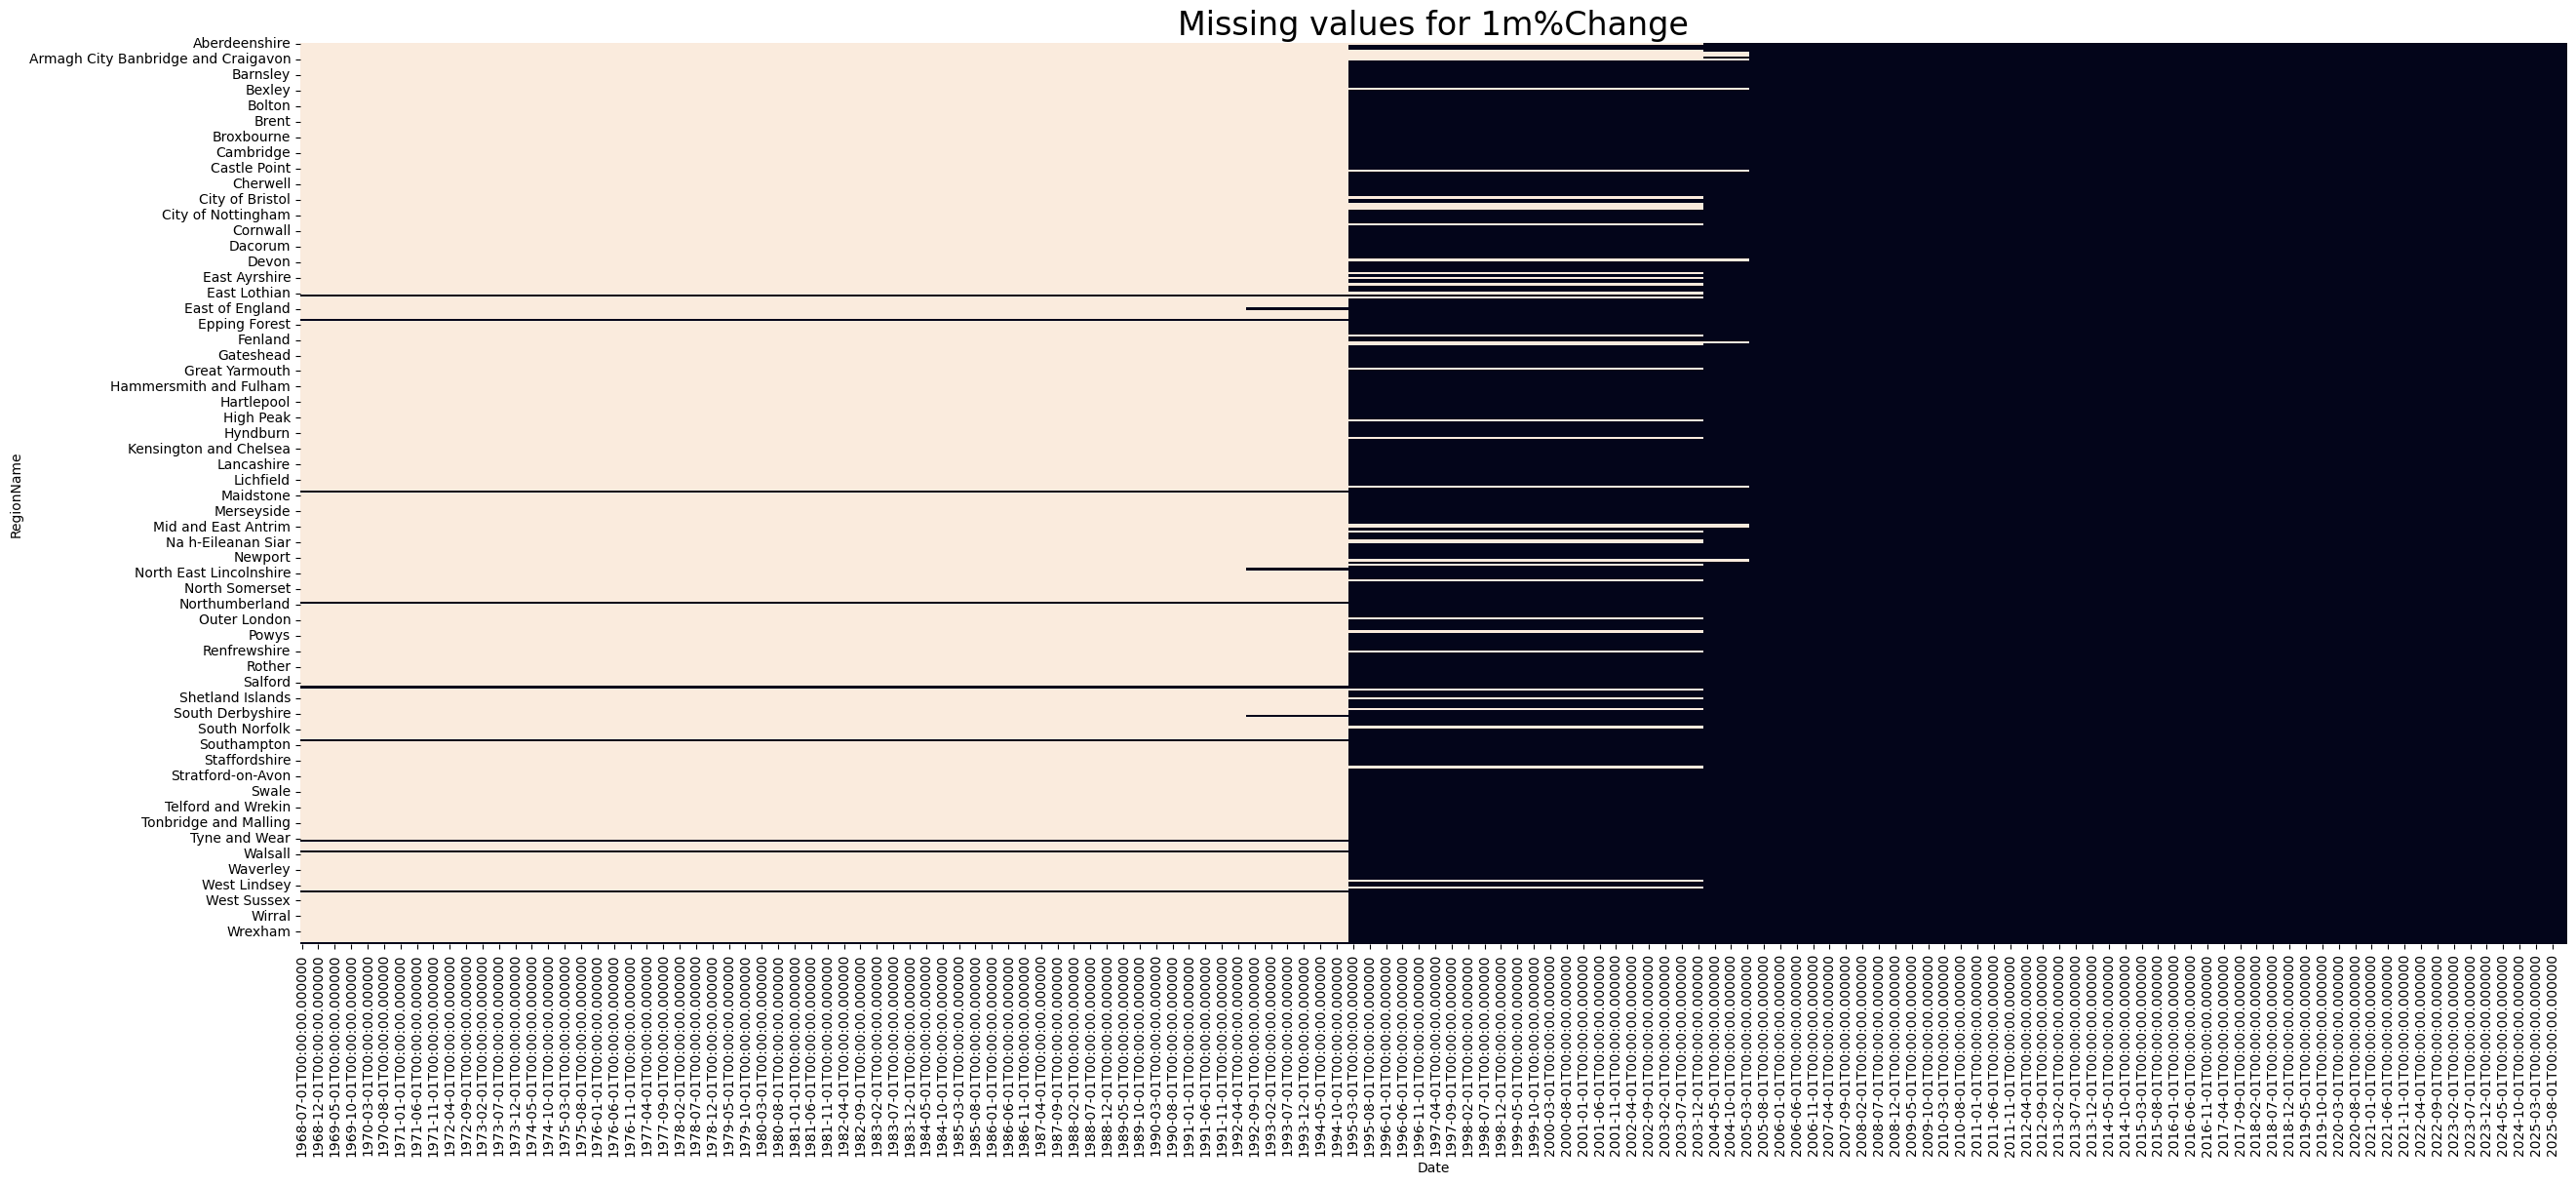

In [96]:
piv_tab_1m = data.pivot_table(values='1m%Change',index='RegionName',columns='Date')
piv_tab_12m = data.pivot_table(values='12m%Change',index='RegionName',columns='Date')
piv_tab_SV = data.pivot_table(values='SalesVolume',index='RegionName',columns='Date')

piv_tabs = [piv_tab_1m, piv_tab_12m,piv_tab_SV]

def plot_piv_tab_heatmap(piv_tab):
    plt.figure(figsize=(12,12))
    
    sns.heatmap(piv_tab.isna(),cbar=False)
    plt.title(f"Missing values for {piv_tab}",fontsize=24)
    plt.show()

for pt in piv_tabs:
    plot

    


In [63]:
data_s_full.sort_values(by=['County','Date'])

,County,Date,AreaCode,AveragePrice,Country,Region
372,Aberdeenshire,1968-04-01,NaN,NaN,NaN,NaN
373,Aberdeenshire,1968-05-01,NaN,NaN,NaN,NaN
374,Aberdeenshire,1968-06-01,NaN,NaN,NaN,NaN
375,Aberdeenshire,1968-07-01,NaN,NaN,NaN,NaN
376,Aberdeenshire,1968-08-01,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
280231,Yorkshire and The Humber,2025-08-01,E12000003,206107.0,E,Yorkshire and the Humber
280232,Yorkshire and The Humber,2025-09-01,E12000003,206581.0,E,Yorkshire and the Humber
280233,Yorkshire and The Humber,2025-10-01,E12000003,206401.0,E,Yorkshire and the Humber
280234,Yorkshire and The Humber,2025-11-01,E12000003,209467.0,E,Yorkshire and the Humber


### 4. Clean full dataset with regions

Let's have a look at our dataset organised as a pivot table a timeseries format.

In [65]:
df_county_date = data_s_full.pivot_table(index='County',columns='Date',values='AveragePrice')
df_county_date

Date,1968-04-01,1968-05-01,1968-06-01,1968-07-01,1968-08-01,1968-09-01,1968-10-01,1968-11-01,1968-12-01,1969-01-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
County,,,,,,,,,,,,,,,,,,,,,
Aberdeenshire,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,193731.0,193159.0,196734.0,200115.0,201317.0,202951.0,201831.0,203136.0,201555.0,202362.0
Adur,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,372721.0,373551.0,376763.0,382977.0,378576.0,381370.0,382180.0,374865.0,372499.0,370708.0
Amber Valley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,224300.0,223602.0,224311.0,224192.0,226413.0,230680.0,235285.0,238335.0,238246.0,234786.0
Angus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,165304.0,166294.0,168141.0,170387.0,170632.0,167862.0,165145.0,167542.0,170210.0,174680.0
Antrim and Newtownabbey,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,189792.0,189463.0,189463.0,189463.0,195765.0,195765.0,195765.0,197918.0,197918.0,197918.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wychavon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,322202.0,317768.0,312704.0,314726.0,324802.0,330999.0,333782.0,331721.0,336679.0,333519.0
Wyre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,191156.0,186363.0,183547.0,178896.0,183701.0,187061.0,188731.0,187052.0,187997.0,193044.0
Wyre Forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,232425.0,229063.0,229142.0,229485.0,236782.0,238175.0,236339.0,235202.0,233338.0,234081.0


### 4.1 Investigating missing values

There does seem to be a lot of missing values however and these may impact our analysis. Let's investigate.

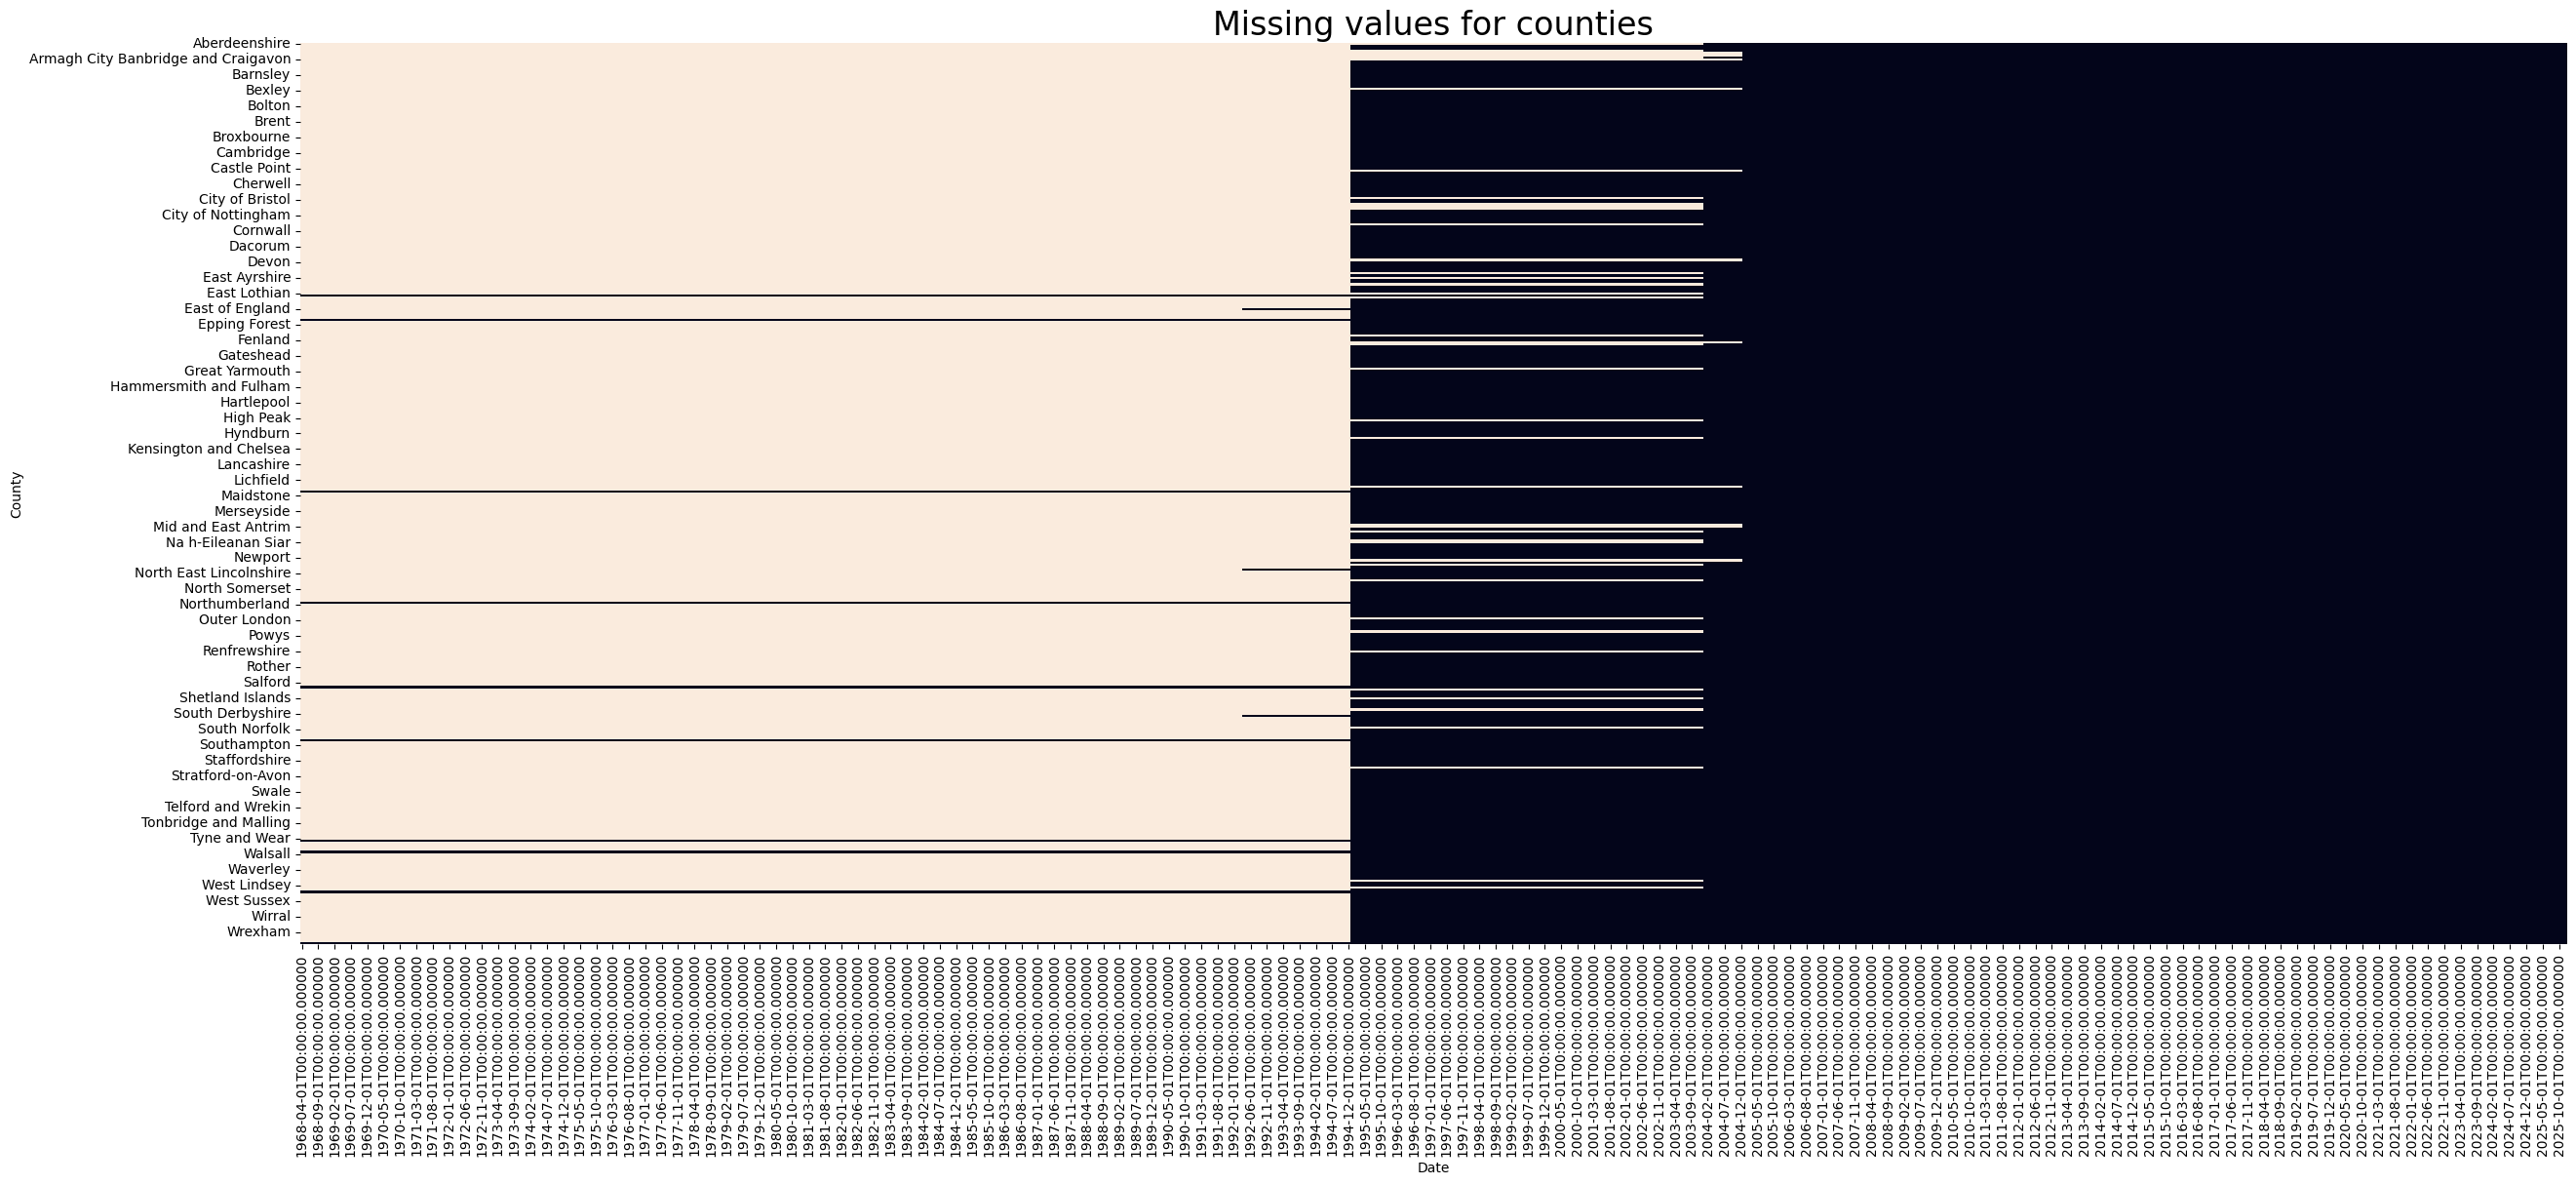

In [67]:
import seaborn as sns
plt.figure(figsize=(30,12))

sns.heatmap(df_county_date.isna(),cbar=False)
plt.title("Missing values for counties",fontsize=24)
plt.show()

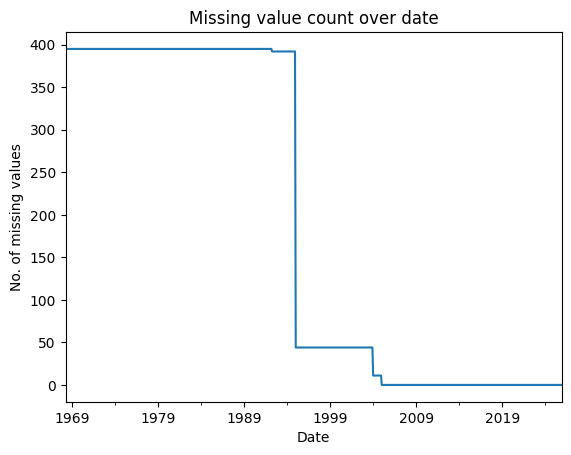

In [68]:
missing_values = df_county_date.isna().sum()
missing_values.plot()
plt.ylabel("No. of missing values")
plt.title("Missing value count over date")
plt.show()

In [69]:
print("Number of missing values 1970",missing_values.loc['1970'].mean())
print("Number of missing values 1990",missing_values.loc['1990'].mean())
print("Number of missing values 1994",missing_values.loc['1994'].mean())
print("Number of missing values 1995",missing_values.loc['1995'].mean())
print("Number of missing values 2000",missing_values.loc['2000'].mean())
print("Number of missing values 2003",missing_values.loc['2003'].mean())
print("Number of missing values 2004",missing_values.loc['2004'].mean())
print("Number of missing values 2005",missing_values.loc['2005'].mean())
print("Number of missing values 2010",missing_values.loc['2010'].mean())

Number of missing values 1970 395.0
Number of missing values 1990 395.0
Number of missing values 1994 392.0
Number of missing values 1995 44.0
Number of missing values 2000 44.0
Number of missing values 2003 44.0
Number of missing values 2004 11.0
Number of missing values 2005 0.0
Number of missing values 2010 0.0


__The dataset exhibits structural missingness prior to 2005, so I restrict analysis to a fully observed balanced panel from 2005 onward.__

In [71]:
data_s_05 = data_s_full[data_s_full['Date']>='2005']
data_s_05.sort_values(by=['County','Date'])
data_s_05

,County,Date,AreaCode,AveragePrice,Country,Region
12,Aberdeenshire,2005-01-01,S12000034,105489.0,S,Scotland
13,Aberdeenshire,2005-02-01,S12000034,101145.0,S,Scotland
14,Aberdeenshire,2005-03-01,S12000034,98196.0,S,Scotland
15,Aberdeenshire,2005-04-01,S12000034,99302.0,S,Scotland
16,Aberdeenshire,2005-05-01,S12000034,105412.0,S,Scotland
...,...,...,...,...,...,...
280231,Yorkshire and The Humber,2025-08-01,E12000003,206107.0,E,Yorkshire and the Humber
280232,Yorkshire and The Humber,2025-09-01,E12000003,206581.0,E,Yorkshire and the Humber
280233,Yorkshire and The Humber,2025-10-01,E12000003,206401.0,E,Yorkshire and the Humber
280234,Yorkshire and The Humber,2025-11-01,E12000003,209467.0,E,Yorkshire and the Humber


In [72]:
data_s_05.isna().sum()

County          0
Date            0
AreaCode        0
AveragePrice    0
Country         0
Region          0
dtype: int64

__Now we have a reduced dataset from 2005 onwards with no missing values.__  
Confirming the list of counties looks ok by visual inspection.

In [74]:
list_of_counties = data_s_05['County'].unique()
for i in list_of_counties:
    print(i,end=", ")    

Aberdeenshire, Adur, Amber Valley, Angus, Antrim and Newtownabbey, Ards and North Down, Argyll and Bute, Armagh City Banbridge and Craigavon, Arun, Ashfield, Ashford, Babergh, Barking and Dagenham, Barnet, Barnsley, Basildon, Basingstoke and Deane, Bassetlaw, Bath and North East Somerset, Bedford, Belfast, Bexley, Birmingham, Blaby, Blackburn with Darwen, Blackpool, Blaenau Gwent, Bolsover, Bolton, Boston, Bournemouth Christchurch and Poole, Bracknell Forest, Bradford, Braintree, Breckland, Brent, Brentwood, Bridgend, Brighton and Hove, Broadland, Bromley, Bromsgrove, Broxbourne, Broxtowe, Buckinghamshire, Burnley, Bury, Caerphilly, Calderdale, Cambridge, Cambridgeshire, Camden, Cannock Chase, Canterbury, Cardiff, Carmarthenshire, Castle Point, Causeway Coast and Glens, Central Bedfordshire, Ceredigion, Charnwood, Chelmsford, Cheltenham, Cherwell, Cheshire East, Cheshire West and Chester, Chesterfield, Chichester, Chorley, City of Aberdeen, City of Bristol, City of Derby, City of Dunde

__Let's output a new csv to work on now our dataset is ready for some further analysis.__

In [217]:
data_s_05.to_csv("../data/house_prices_full_cleaned.csv",index=False)

Let's have a look at that same pivot table now for our reduced date range

In [76]:
df_county_date = data_s_05.pivot_table(index='County',columns='Date',values='AveragePrice')
df_county_date

Date,2005-01-01,2005-02-01,2005-03-01,2005-04-01,2005-05-01,2005-06-01,2005-07-01,2005-08-01,2005-09-01,2005-10-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
County,,,,,,,,,,,,,,,,,,,,,
Aberdeenshire,105489.0,101145.0,98196.0,99302.0,105412.0,110561.0,112337.0,116017.0,117748.0,120861.0,...,193731.0,193159.0,196734.0,200115.0,201317.0,202951.0,201831.0,203136.0,201555.0,202362.0
Adur,183493.0,175825.0,178438.0,179535.0,183259.0,182181.0,179850.0,182674.0,184383.0,186795.0,...,372721.0,373551.0,376763.0,382977.0,378576.0,381370.0,382180.0,374865.0,372499.0,370708.0
Amber Valley,121782.0,122847.0,122490.0,126003.0,126294.0,129078.0,127970.0,126297.0,124372.0,123671.0,...,224300.0,223602.0,224311.0,224192.0,226413.0,230680.0,235285.0,238335.0,238246.0,234786.0
Angus,77436.0,77196.0,78040.0,81245.0,87424.0,89842.0,93388.0,94242.0,96509.0,97747.0,...,165304.0,166294.0,168141.0,170387.0,170632.0,167862.0,165145.0,167542.0,170210.0,174680.0
Antrim and Newtownabbey,107491.0,107491.0,107491.0,107298.0,107298.0,107298.0,116139.0,116139.0,116139.0,120436.0,...,189792.0,189463.0,189463.0,189463.0,195765.0,195765.0,195765.0,197918.0,197918.0,197918.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wychavon,193661.0,192912.0,189999.0,187074.0,191725.0,194765.0,196859.0,195475.0,197418.0,197194.0,...,322202.0,317768.0,312704.0,314726.0,324802.0,330999.0,333782.0,331721.0,336679.0,333519.0
Wyre,137174.0,134850.0,132668.0,133198.0,135366.0,138126.0,141574.0,141390.0,140024.0,138041.0,...,191156.0,186363.0,183547.0,178896.0,183701.0,187061.0,188731.0,187052.0,187997.0,193044.0
Wyre Forest,138423.0,138375.0,139305.0,139231.0,142268.0,145143.0,150411.0,149447.0,148667.0,144913.0,...,232425.0,229063.0,229142.0,229485.0,236782.0,238175.0,236339.0,235202.0,233338.0,234081.0


<Axes: xlabel='Date'>

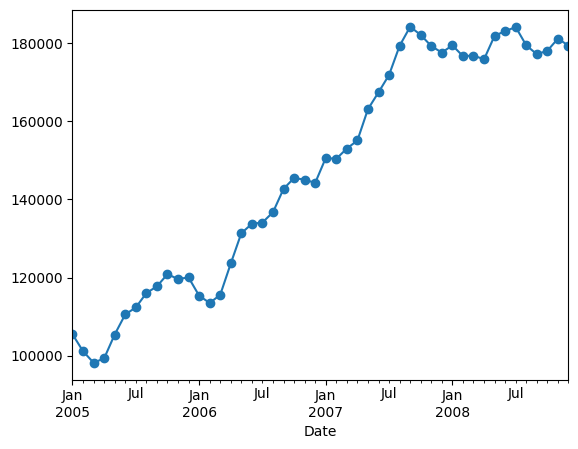

In [78]:
aberdeenshire_data = df_county_date.loc['Aberdeenshire']
aberdeenshire_data['2005':'2008'].plot(marker='o')

In [182]:
max_prices_per_county = df_county_date.T.max().sort_values(ascending=False)
max_prices_per_county

County
Kensington and Chelsea        1656986.0
City of Westminster           1224972.0
City of London                1021539.0
Camden                         948480.0
Hammersmith and Fulham         889834.0
                                ...    
East Ayrshire                  134249.0
City of Kingston upon Hull     132176.0
Burnley                        131476.0
West Dunbartonshire            131097.0
Inverclyde                     121039.0
Length: 405, dtype: float64

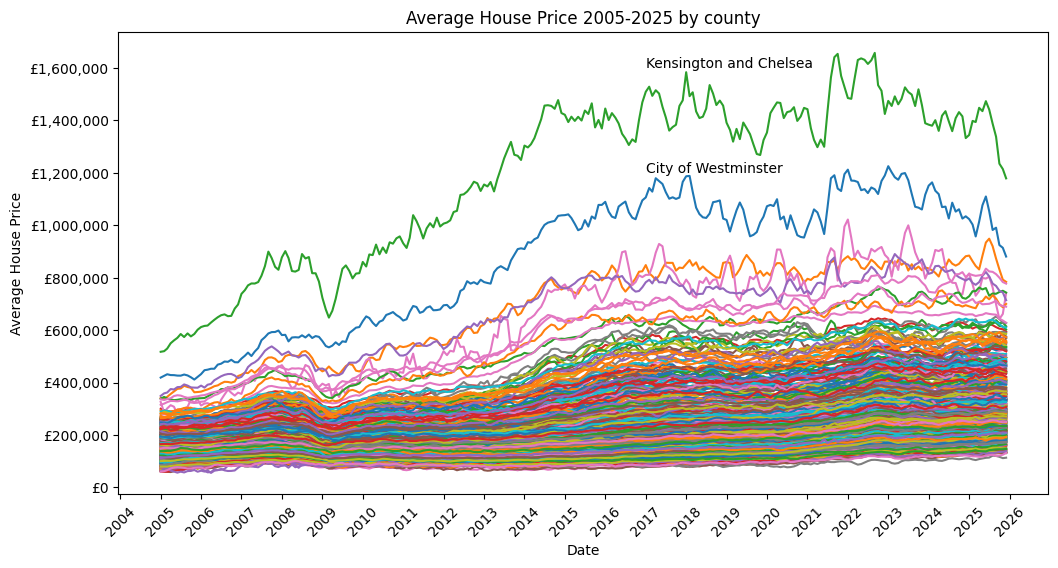

In [204]:
fig,ax = plt.subplots(figsize=(12,6))

ax.plot(df_county_date.T)

ax.set_ylabel('Average House Price')
ax.set_xlabel('Date')
ax.set_title('Average House Price 2005-2025 by county')
ax.ticklabel_format(style='plain',axis='y')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.tick_params(axis='x',rotation=45)
ax.annotate('Kensington and Chelsea',xy=(pd.Timestamp('2017'),1600000))
ax.annotate('City of Westminster',xy=(pd.Timestamp('2017'),1200000))

plt.show()

### 5. Comparing regions

Group by regions and produce a pivot table for average prices for each timestamp.

In [82]:
region_piv_tab = data_s_05.pivot_table(index='Region',columns='Date',values='AveragePrice',aggfunc='mean')
region_piv_tab.sort_index(axis=1)
region_piv_tab

Date,2005-01-01,2005-02-01,2005-03-01,2005-04-01,2005-05-01,2005-06-01,2005-07-01,2005-08-01,2005-09-01,2005-10-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
Region,,,,,,,,,,,,,,,,,,,,,
East Midlands,135652.025000,134888.550000,134657.475000,136147.875000,137647.325000,138591.925000,139518.750000,140186.525000,140797.700000,141025.150000,...,243019.200000,240224.250000,239982.450000,238725.975000,242229.675000,244826.150000,246559.950000,247380.900000,247085.975000,247729.100000
East of England,183885.411765,182642.254902,182186.686275,181707.313725,183197.019608,184573.470588,186078.941176,186531.941176,187117.705882,187021.019608,...,356371.078431,353884.294118,354077.235294,354393.117647,358487.823529,361069.784314,361489.725490,362640.725490,362187.588235,361780.725490
London,262901.694444,260937.916667,262153.166667,264247.027778,265887.666667,267099.222222,268456.472222,269961.361111,270563.305556,269499.222222,...,595311.277778,599176.416667,602719.305556,608022.055556,606972.250000,603363.944444,599102.055556,586651.111111,583252.638889,580491.361111
North East England,106318.571429,106144.428571,105848.714286,107053.642857,109426.714286,111506.285714,113511.857143,115401.428571,115864.500000,115927.857143,...,160360.642857,158182.214286,158019.285714,157361.785714,160348.500000,162621.928571,163243.714286,163830.000000,165605.000000,165885.714286
North West England,114794.666667,114042.410256,114315.076923,115462.641026,117884.435897,119877.358974,121608.051282,122708.333333,123309.256410,123454.897436,...,208643.512821,205967.025641,205867.282051,204574.128205,208531.948718,211208.205128,212062.615385,212314.564103,212575.025641,213683.974359
Northern Ireland,106654.416667,106654.416667,106654.416667,111370.416667,111370.416667,111370.416667,118338.083333,118338.083333,118338.083333,122772.916667,...,185048.000000,186326.666667,186326.666667,186326.666667,194596.166667,194596.166667,194596.166667,197757.916667,197757.916667,197757.916667
Scotland,91146.151515,90641.303030,90538.909091,93083.454545,96024.393939,99854.484848,102080.636364,103862.393939,104552.818182,104431.575758,...,185201.333333,185761.909091,186976.212121,188140.696970,189543.181818,191582.515152,192532.121212,193455.515152,193265.757576,192545.000000
South East England,205182.816901,204076.126761,203639.211268,204443.042254,205204.352113,206191.352113,206985.253521,207749.507042,208519.859155,208343.971831,...,394221.690141,393235.492958,392234.887324,392727.929577,394259.000000,397504.985915,397738.746479,398121.239437,396416.971831,394392.830986
South West England,174834.551724,174706.275862,174172.758621,174000.344828,174541.862069,175572.206897,177320.655172,178265.862069,179181.206897,179194.620690,...,307944.896552,305494.896552,304830.517241,303813.862069,307452.586207,310474.413793,311840.827586,310846.068966,311101.482759,309878.448276


### Plot average price for regions over time

<Axes: xlabel='Date'>

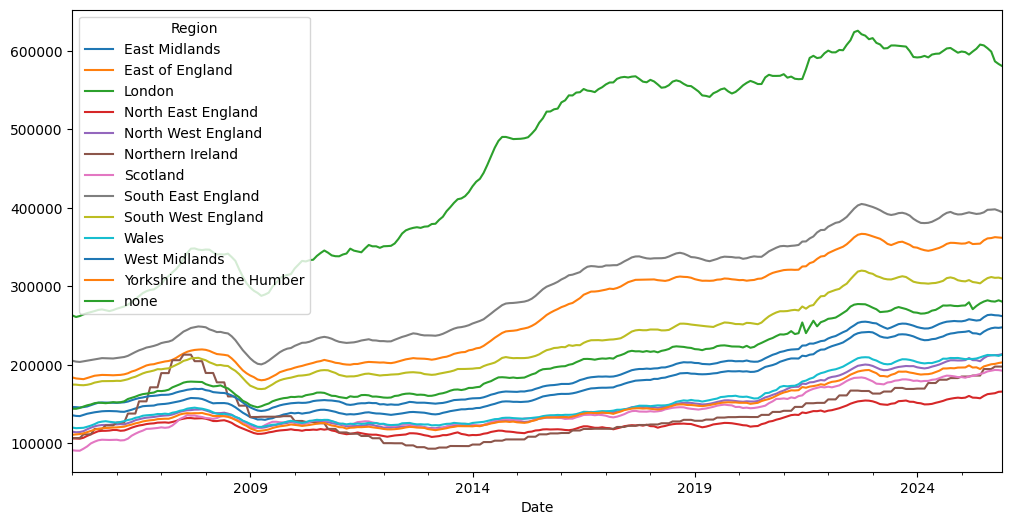

In [84]:
import matplotlib.pyplot as plt
region_piv_tab.T.plot(figsize=(12,6))


This may be a bit of a crude analysis however, consider factors such as the influence of varying house sizes for example.


In [86]:
'''
east_of_england = ['Babergh', 'Basildon', 'Bedford', 'Braintree', 'Breckland', 'Brentwood', 'Broadland',
                'Broxbourne', 'Cambridge', 'Castle Point', 'Central Bedfordshire', 'Chelmsford',
                'Colchester', 'Dacorum', 'East Cambridgeshire', 'East Hertfordshire', 'East Suffolk',
                'Epping Forest', 'Fenland', 'Great Yarmouth', 'Harlow', 'Hertsmere', 'Huntingdonshire',
                'Ipswich', 'Kings Lynn and West Norfolk', 'Luton', 'Maldon', 'Mid Suffolk', 'North Hertfordshire', 
                   'North Norfolk', 'Norwich', 'Peterborough', 'Rochford', 'South Cambridgeshire', 'South Norfolk', 
                   'Southend-on-Sea', 'St. Albans', 'Stevenage', 'Tendring',
                'Three Rivers', 'Thurrock', 'Uttlesford', 'Watford', 'Welwyn Hatfield', 'West Suffolk']

# check diff
east_diff = set(east_of_england) - set(region_names)
print(east_diff)

east_midlands = ['Amber Valley', 'Ashfield', 'Bassetlaw', 'Blaby', 'Bolsover', 'Boston', 'Broxtowe',
                'Charnwood', 'Chesterfield', 'Derby', 'Derbyshire Dales', 'East Lindsey', 'Erewash',
                'Gedling', 'Harborough', 'High Peak', 'Hinckley and Bosworth', 'Leicester', 'Lincoln',
                'Mansfield', 'Melton', 'Newark and Sherwood', 'North East Derbyshire', 'North Kesteven', 'North West Leicestershire', 
                 'North Northamptonshire', 'Nottingham','Oadby and Wigston', 'Rushcliffe', 'Rutland', 'South Derbyshire', 
                 'South Holland', 'South Kesteven', 'West Lindsey', 'West Northamptonshire']

# check diff
east_m_diff = set(east_midlands) - set(region_names)
print(east_m_diff)
'''

"\neast_of_england = ['Babergh', 'Basildon', 'Bedford', 'Braintree', 'Breckland', 'Brentwood', 'Broadland',\n                'Broxbourne', 'Cambridge', 'Castle Point', 'Central Bedfordshire', 'Chelmsford',\n                'Colchester', 'Dacorum', 'East Cambridgeshire', 'East Hertfordshire', 'East Suffolk',\n                'Epping Forest', 'Fenland', 'Great Yarmouth', 'Harlow', 'Hertsmere', 'Huntingdonshire',\n                'Ipswich', 'Kings Lynn and West Norfolk', 'Luton', 'Maldon', 'Mid Suffolk', 'North Hertfordshire', \n                   'North Norfolk', 'Norwich', 'Peterborough', 'Rochford', 'South Cambridgeshire', 'South Norfolk', \n                   'Southend-on-Sea', 'St. Albans', 'Stevenage', 'Tendring',\n                'Three Rivers', 'Thurrock', 'Uttlesford', 'Watford', 'Welwyn Hatfield', 'West Suffolk']\n\n# check diff\neast_diff = set(east_of_england) - set(region_names)\nprint(east_diff)\n\neast_midlands = ['Amber Valley', 'Ashfield', 'Bassetlaw', 'Blaby', 'Bolsover'

### Use the government uk counties and unitary boundaries map
https://www.data.gov.uk/dataset/85228aec-fe0e-49bf-9455-df000d61e731/counties-and-unitary-authorities-may-2023-boundaries-uk-bgc

In [88]:
import geopandas as gpd
geodata = "../data/uk-counties.geojson"
map_df = gpd.read_file(geodata)
print(map_df.columns)

Index(['FID', 'CTYUA23CD', 'CTYUA23NM', 'CTYUA23NMW', 'BNG_E', 'BNG_N', 'LONG',
       'LAT', 'GlobalID', 'geometry'],
      dtype='str')
